In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme()

In [ ]:
data_dir = "/home/patricka/Projects/DataScienceAndMachineLearning/Data/"

df = pd.read_csv(data_dir + 'AirQualityUCI.csv', sep = ";")
df = df.dropna(axis=0, how="all").dropna(axis=1, how="all")
df

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,10/03/2004,18.00.00,"2,6",1360.0,150.0,"11,9",1046.0,166.0,1056.0,113.0,1692.0,1268.0,"13,6","48,9","0,7578"
1,10/03/2004,19.00.00,2,1292.0,112.0,"9,4",955.0,103.0,1174.0,92.0,1559.0,972.0,"13,3","47,7","0,7255"
2,10/03/2004,20.00.00,"2,2",1402.0,88.0,"9,0",939.0,131.0,1140.0,114.0,1555.0,1074.0,"11,9","54,0","0,7502"
3,10/03/2004,21.00.00,"2,2",1376.0,80.0,"9,2",948.0,172.0,1092.0,122.0,1584.0,1203.0,"11,0","60,0","0,7867"
4,10/03/2004,22.00.00,"1,6",1272.0,51.0,"6,5",836.0,131.0,1205.0,116.0,1490.0,1110.0,"11,2","59,6","0,7888"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9352,04/04/2005,10.00.00,"3,1",1314.0,-200.0,"13,5",1101.0,472.0,539.0,190.0,1374.0,1729.0,"21,9","29,3","0,7568"
9353,04/04/2005,11.00.00,"2,4",1163.0,-200.0,"11,4",1027.0,353.0,604.0,179.0,1264.0,1269.0,"24,3","23,7","0,7119"
9354,04/04/2005,12.00.00,"2,4",1142.0,-200.0,"12,4",1063.0,293.0,603.0,175.0,1241.0,1092.0,"26,9","18,3","0,6406"
9355,04/04/2005,13.00.00,"2,1",1003.0,-200.0,"9,5",961.0,235.0,702.0,156.0,1041.0,770.0,"28,3","13,5","0,5139"


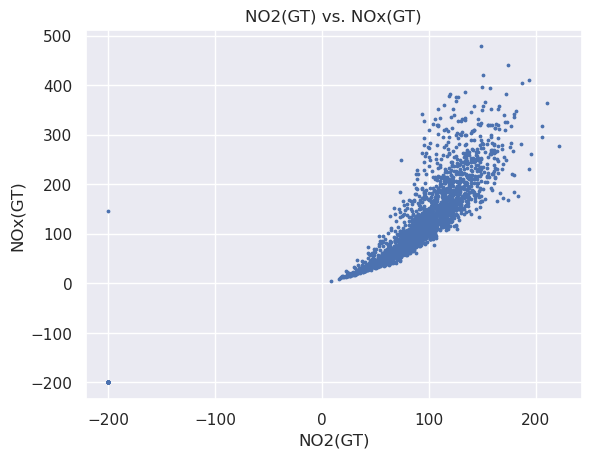

In [137]:
training_cutoff = 2500
df_slice = df.iloc[0:training_cutoff, :]
X = df_slice['NO2(GT)']
y = df_slice['NOx(GT)']
plt.xlabel("NO2(GT)")
plt.ylabel("NOx(GT)")
plt.title(f"NO2(GT) vs. NOx(GT)")
plt.scatter(X, y, s = 3)
plt.show()

- calculate partial derivatives of cost function, apply gradient descent to the cost function
- use gradient descent to step weights and biases. full gradient is the sum of partials * 1/N (batch gradient descent)
- batch gradient descent is unnecessary to find local minima, can update w.r.t. one data entry at a time (stochastic gradient descent)
- stochastic gradient descent updates weights and biases with one data entry each time, essentially the same as batch gradient descent but uses less memory
  - is this not slower? 

each class should contain a training method and a prediction method
train function should look like train(X, y, keywords...)
predict should be predict(X), predicts a y value based on weights and bias created in training
create custom contourf function to visualize decision boundaries and probabilities

In [ ]:
class LinearRegressionNeuron():
    def __init__(self):
        pass
        
    def train(self, X, y, eta = 0.0001, epochs=100):
        self.n = X.shape[0]
        self.weight = np.random.rand()
        self.bias = np.random.rand()
        errors = np.empty(epochs)
        for epoch in range(epochs):
            y_hats = np.empty(self.n)
            for i in range(self.n):
                y_hats[i] = self.predict(X[i])
            for i in range(self.n):
                self.weight += -eta * (y_hats[i] - y[i]) * X[i] / self.n
                self.bias += -eta * (y_hats[i] - y[i]) / self.n
            errors[epoch] = (self.cost(y, y_hats))
        return errors
    
    def cost(self, y, y_hat):
        cost = 0.0
        for i in range(self.n):
            cost += (y_hat[i] - y[i])**2
        cost /= 2.0*self.n
        return cost

    def predict(self, x):
        return self.weight * x + self.bias

In [112]:
neuron = LinearRegressionNeuron()
errors = neuron.train(X, y)

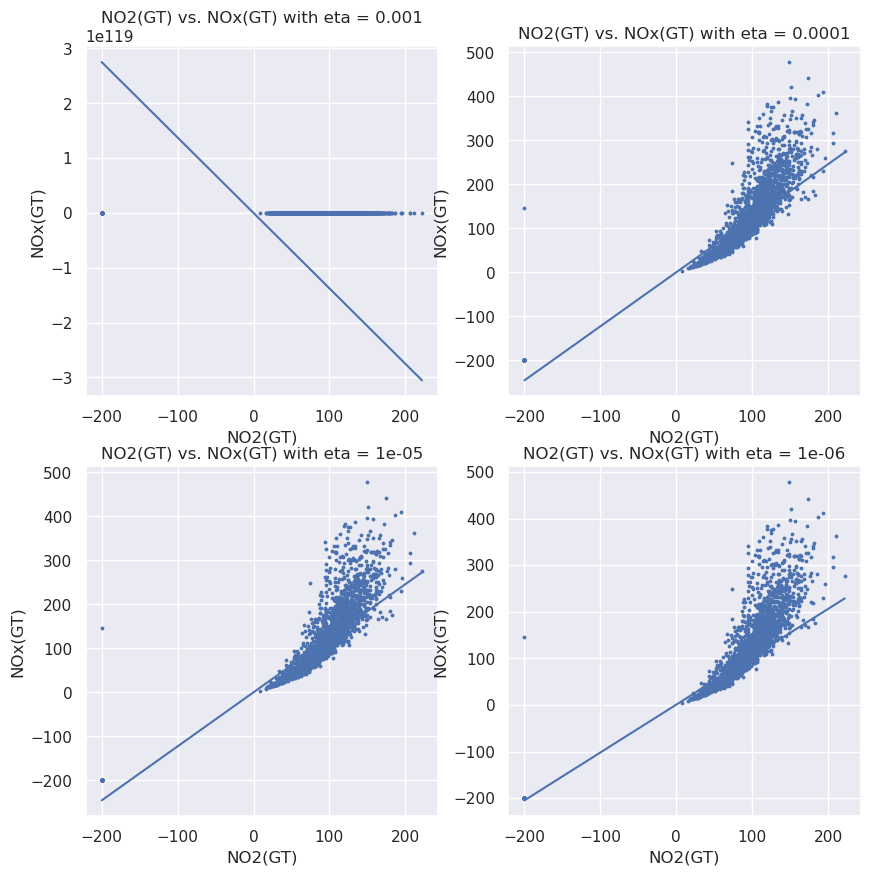

In [140]:
fig, axs = plt.subplots(2, 2, figsize = (10, 10))
t = np.linspace(min(X), max(X), 1000)

Neuron_1 = LinearRegressionNeuron()
neuron_1_eta = 0.001
errors_1 = Neuron_1.train(X, y, eta = neuron_1_eta, epochs = 100)
t_y_1 = [Neuron_1.predict(t_i) for t_i in t]
axs[0, 0].plot(t, t_y_1)
axs[0, 0].set_xlabel("NO2(GT)")
axs[0, 0].set_ylabel("NOx(GT)")
axs[0, 0].set_title(f"NO2(GT) vs. NOx(GT) with eta = {neuron_1_eta}")
axs[0, 0].scatter(X, y, s = 3)

Neuron_2 = LinearRegressionNeuron()
neuron_2_eta = 0.0001
errors_2 = Neuron_2.train(X, y, eta = neuron_2_eta, epochs = 100)
t_y_2 = [Neuron_2.predict(t_i) for t_i in t]
axs[0, 1].plot(t, t_y_2)
axs[0, 1].set_xlabel("NO2(GT)")
axs[0, 1].set_ylabel("NOx(GT)")
axs[0, 1].set_title(f"NO2(GT) vs. NOx(GT) with eta = {neuron_2_eta}")
axs[0, 1].scatter(X, y, s = 3)

Neuron_3 = LinearRegressionNeuron()
neuron_3_eta = 0.00001
errors_3 = Neuron_3.train(X, y, eta = neuron_3_eta, epochs = 100)
t_y_3 = [Neuron_3.predict(t_i) for t_i in t]
axs[1, 0].plot(t, t_y_3)
axs[1, 0].set_xlabel("NO2(GT)")
axs[1, 0].set_ylabel("NOx(GT)")
axs[1, 0].set_title(f"NO2(GT) vs. NOx(GT) with eta = {neuron_3_eta}")
axs[1, 0].scatter(X, y, s = 3)

Neuron_4 = LinearRegressionNeuron()
neuron_4_eta = 0.000001
errors_4 = Neuron_4.train(X, y, eta = neuron_4_eta, epochs = 100)
t_y_4 = [Neuron_4.predict(t_i) for t_i in t]
axs[1, 1].plot(t, t_y_4)
axs[1, 1].set_xlabel("NO2(GT)")
axs[1, 1].set_ylabel("NOx(GT)")
axs[1, 1].set_title(f"NO2(GT) vs. NOx(GT) with eta = {neuron_4_eta}")
axs[1, 1].scatter(X, y, s = 3)

Text(0.5, 1.0, 'Error with eta = 1e-06')

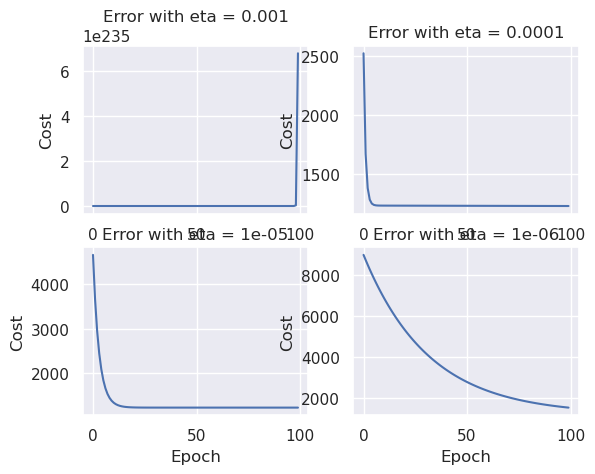

In [141]:
fig, ax = plt.subplots(2, 2)


ax[0, 0].plot(errors_1)
ax[0, 0].set_xlabel("Epoch")
ax[0, 0].set_ylabel("Cost")
ax[0, 0].set_title(f"Error with eta = {neuron_1_eta}")

ax[0, 1].plot(errors_2)
ax[0, 1].set_xlabel("Epoch")
ax[0, 1].set_ylabel("Cost")
ax[0, 1].set_title(f"Error with eta = {neuron_2_eta}")

ax[1, 0].plot(errors_3)
ax[1, 0].set_xlabel("Epoch")
ax[1, 0].set_ylabel("Cost")
ax[1, 0].set_title(f"Error with eta = {neuron_3_eta}")

ax[1, 1].plot(errors_4)
ax[1, 1].set_xlabel("Epoch")
ax[1, 1].set_ylabel("Cost")
ax[1, 1].set_title(f"Error with eta = {neuron_4_eta}")

Minimum error across any learning rate:

In [143]:
min(np.concatenate((errors_1, errors_2, errors_3, errors_4)))

np.float64(1229.2360977830656)